<div style="background-color:#EFF5FF; padding:22px; border-radius:10px; border-left:8px solid #0047AB;">
<h1 style="margin-bottom:0;"><b>Machine Learning II</b></h1>
<h3><b>Customer Segmentation — Geographic Exploration</b></h3>
<p style="font-size:15px; margin-top:14px;">
Here we explore <i>where</i> our customers are. The goal is to understand the spatial footprint of the
base and check whether location carries useful signal. Our conclusion (used in the clustering notebook)
is that latitude/longitude should be treated as a <b>validation</b> variable, not as a clustering feature:
the customers are tightly concentrated around Lisbon, so geography mostly reflects the city layout rather
than distinct behaviour. The heavy plotting logic lives in <code>utils_geographic.py</code>.</p></div>

<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>1. Imports & Data</b></h3></div>

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd

import utils_geographic as geo

pd.set_option("display.max_columns", None)

We load the preprocessed dataset (the one exported by the customer-info notebook), which already carries clean coordinates for every customer.

In [2]:
# Look for the file in the usual places instead of hardcoding an absolute path
candidates = ["info_clustering_unscaled.csv",
              "../datasets/info_clustering_unscaled.csv",
              "datasets/info_clustering_unscaled.csv",
              "customer_info_clean.csv",
              "../datasets/customer_info_clean.csv"]
path = next((p for p in candidates if os.path.exists(p)), candidates[0])

customer_info = pd.read_csv(path, index_col="customer_id")
print(f"Loaded {path} | shape: {customer_info.shape}")
customer_info[["latitude", "longitude"]].head()

Loaded info_clustering_unscaled.csv | shape: (33038, 24)


,latitude,longitude
customer_id,,
3,38.794428,-9.215739
4,38.751711,-9.179611
5,38.780678,-9.160656
7,38.739548,-9.148679
8,38.733071,-9.188188


<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>2. Coordinate Coverage & Basic Statistics</b></h3></div>

In [3]:
# How many customers can we actually place on a map?
geo.coordinate_coverage(customer_info)

total_customers        33038.0
with_coordinates       33038.0
missing_coordinates        0.0
coverage_percent         100.0
dtype: float64

In [4]:
# Spread of the coordinates - a small std means everyone is packed together
geo.geographic_summary(customer_info)

,latitude,longitude
min,38.6880,-9.2330
max,38.8237,-9.0357
mean,38.7497,-9.1545
std,0.0225,0.0286


<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>3. Where Are the Customers?</b></h3></div>

A raw scatter already shows the shape of the base: a dense core with a lighter halo around it.

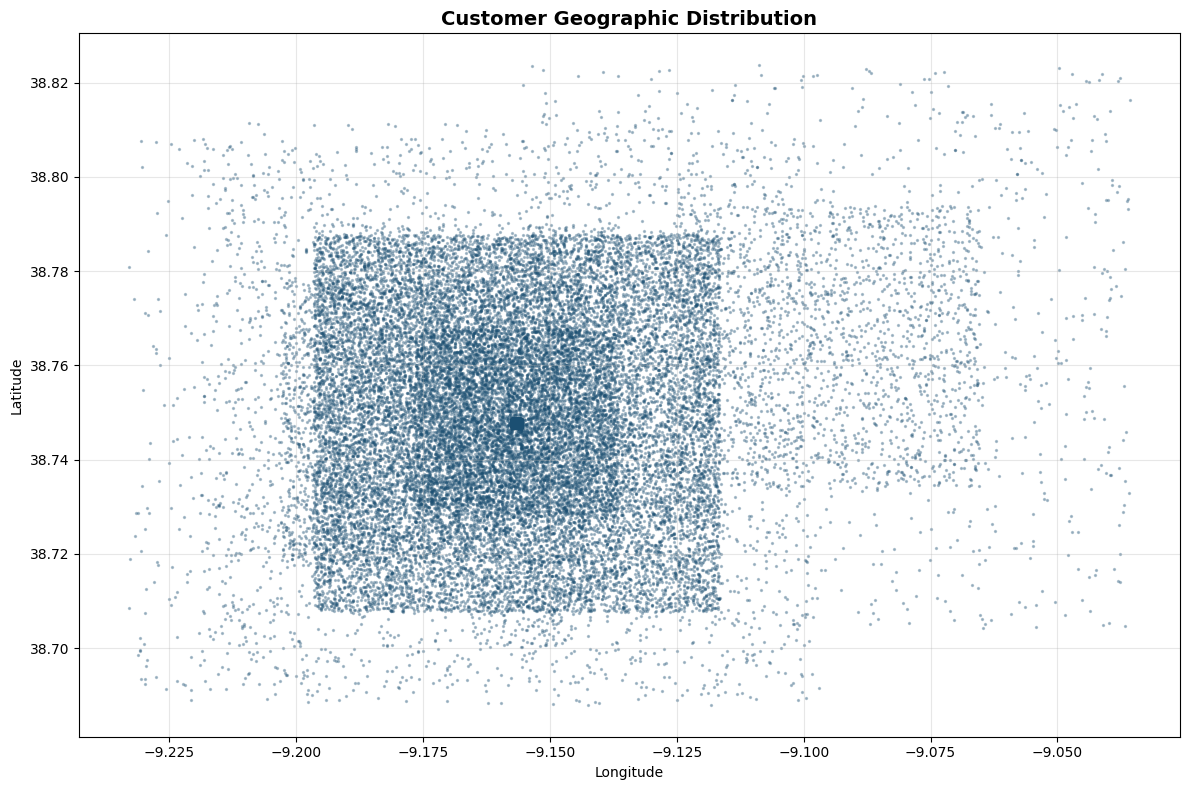

In [5]:
geo.plot_scatter_distribution(customer_info)

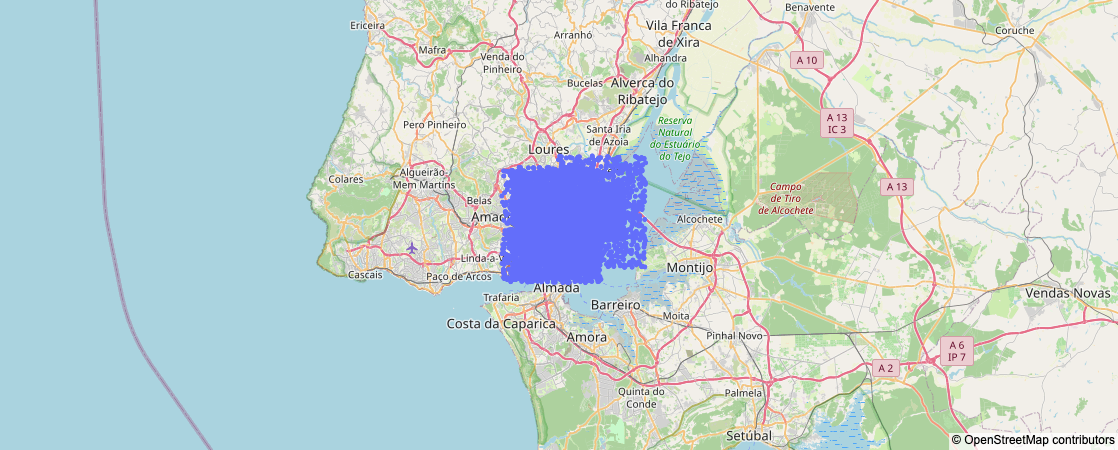

In [6]:
# Interactive version on a real map background
geo.plotly_scatter_map(customer_info, zoom=9).show()

<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>4. Density Maps</b></h3></div>

The hexbin map (log scale) makes the concentration obvious; the Folium map lets us zoom into the clusters interactively.

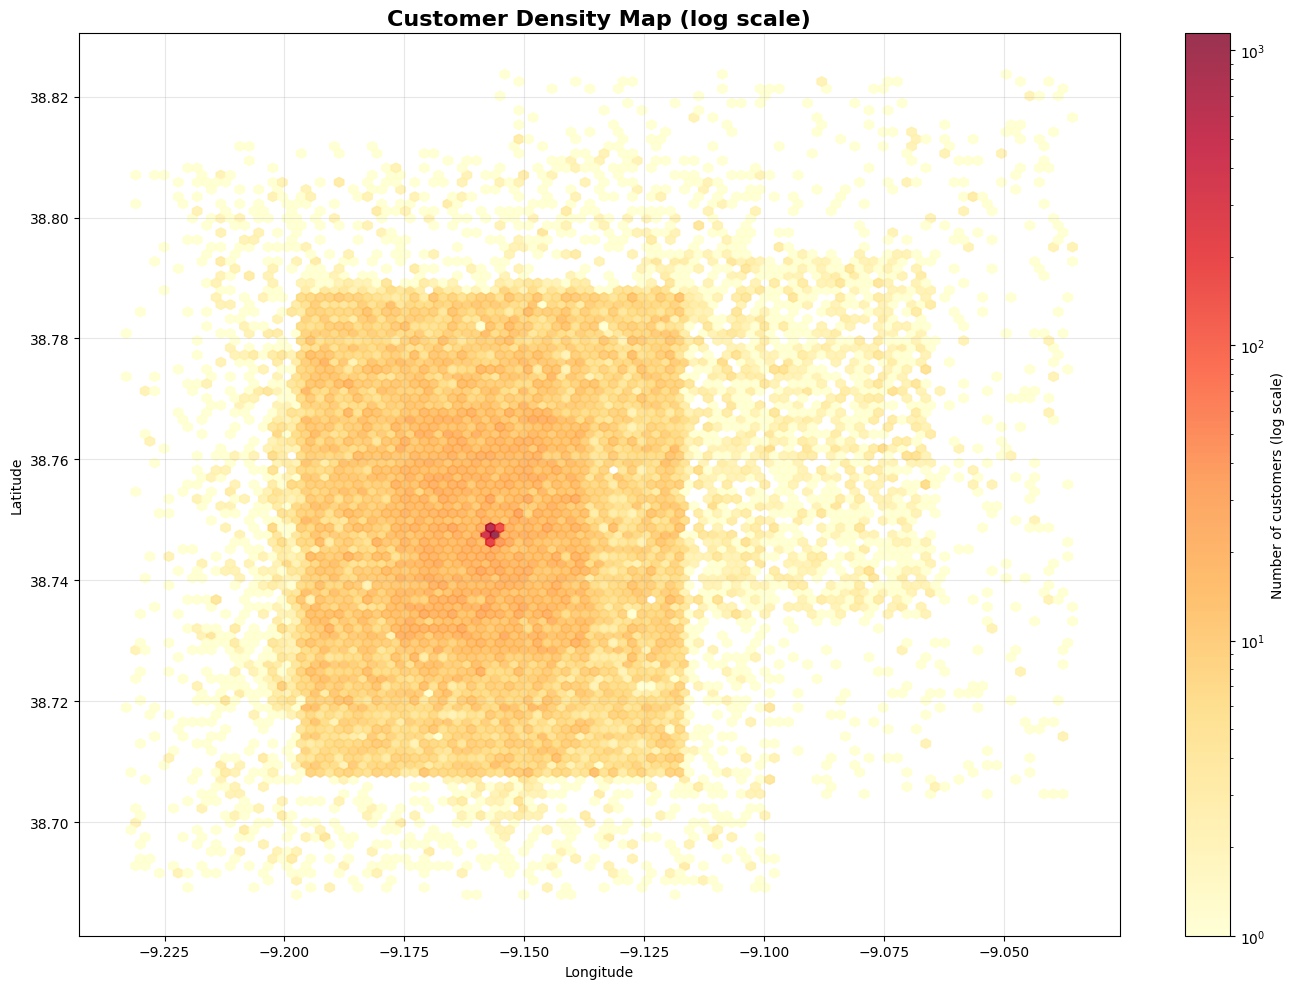

In [7]:
geo.plot_density_hexbin(customer_info, gridsize=100)

In [8]:
# Marker-cluster map (sampled for responsiveness)
geo.folium_cluster_map(customer_info, sample_size=5000)

In [9]:
# Heatmap view of the same density
geo.folium_heatmap(customer_info, sample_size=10000)

<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>5. Zooming Into the Densest Area</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">
We locate the single busiest spot, draw a small bounding box around the dense central area, and compare
that pocket against the global averages. If a dense area behaved very differently from everyone else,
that would be a reason to keep geography in the model — here the differences are modest, which supports
treating location as context rather than as a clustering driver.</div>

In [10]:
# Centre of the busiest hexbin cell
hot_lat, hot_lon = geo.find_densest_point(customer_info, gridsize=50)
print(f"Highest-density point: lat={hot_lat}, lon={hot_lon}")

Highest-density point: lat=38.7486, lon=-9.156


In [11]:
# Bounding box around the dense central area (Lisbon)
lat_range = (38.73, 38.77)
lon_range = (-9.18, -9.12)

dense_area = geo.filter_bounding_box(customer_info, lat_range, lon_range)
dense_area.head()

Customers in region: 15,045 (45.54% of total)


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
4,0.0,2.0,130.0,0.149890,1,38.751711,-9.179611,-0.148236,-7.395953e-01,50.0,1,0,13.0,1.0,0.676815,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.032867,0.064054,9.915120
7,2.0,1.0,92.0,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,0,1,5.0,0.0,0.501137,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.012306,0.184658,9.612667
9,1.0,6.0,84.0,0.150646,1,38.735577,-9.172423,1.000000,1.110223e-16,57.0,2,0,15.0,2.0,0.779210,0.080514,0.019138,0.017112,0.001273,0.003583,0.024182,0.009890,0.065099,9.962454
10,0.0,1.0,202.0,0.275412,1,38.730322,-9.144022,0.707107,-7.071068e-01,54.0,3,1,12.0,3.0,0.623392,0.035991,0.015080,0.055220,0.039158,0.048296,0.024835,0.003336,0.154693,10.482256
12,0.0,2.0,29.0,0.700251,0,38.748616,-9.167756,-1.000000,-1.665335e-16,26.0,3,0,8.0,0.0,0.724286,0.009755,0.004682,0.120883,0.010848,0.046668,0.052521,0.004995,0.025363,9.458372


In [12]:
# Does this dense pocket spend/behave differently from the whole base?
feature_cols = [c for c in customer_info.columns
                if c.startswith("pct_spend_")] + ["customer_age", "total_children",
                                                   "percentage_of_products_bought_promotion"]

geo.compare_region_to_global(dense_area, customer_info, feature_cols)

,feature,region_avg,global_avg,diff_vs_global_%
1,pct_spend_vegetables,0.04,0.04,-13.3
2,pct_spend_nonalcohol_drinks,0.02,0.02,-9.0
6,pct_spend_hygiene,0.04,0.04,-8.8
8,pct_spend_technology,0.12,0.13,-7.4
5,pct_spend_fish,0.03,0.03,6.6
9,customer_age,52.08,54.55,-4.5
4,pct_spend_meat,0.04,0.04,4.3
0,pct_spend_groceries,0.66,0.65,2.8
10,total_children,1.97,1.99,-1.4
7,pct_spend_petfood,0.02,0.02,1.1


<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>6. Takeaways</b></h3>
<ul>
<li>Coordinates are available for essentially the whole base, all within the Lisbon metropolitan area.</li>
<li>The base is heavily concentrated in a central pocket, with a lighter surrounding halo.</li>
<li>The densest area's spending profile is close to the global average, so geography does not split
customers into clearly different behavioural groups on its own.</li>
<li><b>Decision:</b> latitude/longitude are excluded from the behavioural clustering and kept only to
describe and validate the resulting segments.</li>
</ul></div>